In [1]:
import os

PROJECT_ROOT = r"C:\Users\Aanchal Shah\OneDrive\Desktop\InsightAgent"
if os.getcwd() != PROJECT_ROOT:
    os.chdir(PROJECT_ROOT)
print("Working directory:", os.getcwd())

Working directory: C:\Users\Aanchal Shah\OneDrive\Desktop\InsightAgent


In [2]:
from typing import TypedDict, List, Optional

class InsightAgentState(TypedDict):
    user_question: str
    investigation_type: List[str]
    review_findings: Optional[dict]
    delivery_findings: Optional[dict]
    seller_findings: Optional[dict]
    category_findings: Optional[dict]
    root_cause_summary: Optional[str]
    final_report: Optional[str]

In [8]:
def planner_agent(state: InsightAgentState) -> dict:
    question = state['user_question'].lower()
    domains = []

    review_keywords = ['review', 'rating', 'satisfaction', 'unhappy', 'happy', 'negative']
    if any(kw in question for kw in review_keywords):
        domains.append('review')

    delivery_keywords = ['deliver', 'delay', 'late', 'slow', 'shipping']
    if any(kw in question for kw in delivery_keywords):
        domains.append('delivery')

    seller_keywords = ['seller', 'vendor', 'supplier']
    if any(kw in question for kw in seller_keywords):
        domains.append('seller')

    category_keywords = ['categor', 'product type']
    if any(kw in question for kw in category_keywords):
        domains.append('category')

    # Narrower broad-framing trigger: only genuinely ambiguous "what factors/what's risky"
    # phrasing, which doesn't name any specific mechanism
    broad_framing_keywords = ['risky', 'risk', 'factors']
    if any(kw in question for kw in broad_framing_keywords):
        for d in ['review', 'delivery', 'seller', 'category']:
            if d not in domains:
                domains.append(d)

    if not domains:
        domains = ['review', 'delivery', 'seller', 'category']

    return {'investigation_type': domains}


In [9]:
all_questions = test_questions + remaining_questions

for q in all_questions:
    fake_state = {'user_question': q}
    result = planner_agent(fake_state)
    print(f"{q}\n  -> {result}\n")

Why are customer review scores low?
  -> {'investigation_type': ['review']}

Which sellers contribute most to delays?
  -> {'investigation_type': ['delivery', 'seller']}

Which categories suffer from delivery issues?
  -> {'investigation_type': ['delivery', 'category']}

Which states have the slowest deliveries?
  -> {'investigation_type': ['delivery']}

What is causing poor customer satisfaction?
  -> {'investigation_type': ['review']}

Why are customers unhappy?
  -> {'investigation_type': ['review']}

Which factors affect customer ratings the most?
  -> {'investigation_type': ['review', 'delivery', 'seller', 'category']}

What drives negative reviews?
  -> {'investigation_type': ['review']}

Why are deliveries delayed?
  -> {'investigation_type': ['delivery']}

What causes late deliveries?
  -> {'investigation_type': ['delivery']}

Which sellers negatively affect customer experience?
  -> {'investigation_type': ['review', 'seller']}

Who are the worst-performing sellers?
  -> {'inve

In [12]:
from langgraph.graph import StateGraph, START, END

In [13]:
graph_builder = StateGraph(InsightAgentState)

# Add the planner as a node
graph_builder.add_node("planner", planner_agent)

# Wire it: START -> planner -> END (minimal graph, just one real node for now)
graph_builder.add_edge(START, "planner")
graph_builder.add_edge("planner", END)

# Compile it into a runnable graph
graph = graph_builder.compile()

In [14]:
result = graph.invoke({"user_question": "Which sellers have the highest delay rates?"})
print(result)

{'user_question': 'Which sellers have the highest delay rates?', 'investigation_type': ['delivery', 'seller']}


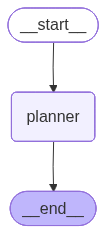

In [15]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

## Review Agent

In [16]:
import pandas as pd

# Load once, so we don't re-read the CSV inside every agent call
master_df = pd.read_csv('data/processed/master_df.csv')

def review_agent(state: InsightAgentState) -> dict:
    df = master_df

    avg_review = df['review_score'].mean()
    delayed_avg_review = df[df['delay_flag'] == True]['review_score'].mean()
    ontime_avg_review = df[df['delay_flag'] == False]['review_score'].mean()

    findings = {
        'avg_review_score': round(avg_review, 2),
        'delayed_order_review_score': round(delayed_avg_review, 2),
        'ontime_order_review_score': round(ontime_avg_review, 2),
    }

    return {'review_findings': findings}

In [17]:
test_state = {'user_question': 'test', 'investigation_type': ['review']}
print(review_agent(test_state))

{'review_findings': {'avg_review_score': np.float64(4.03), 'delayed_order_review_score': np.float64(2.55), 'ontime_order_review_score': np.float64(4.21)}}


In [ ]:
# shows that delay is one of the strongest drivers of dissatisfaction in this dataset

In [18]:
def route_after_planner(state: InsightAgentState):
    # Return the list of agent node names that should run, based on investigation_type
    next_nodes = []
    if 'review' in state['investigation_type']:
        next_nodes.append('review_agent_node')
    # we'll add delivery/seller/category here once those agents exist
    return next_nodes if next_nodes else END

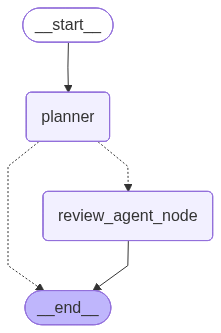

In [23]:
graph_builder = StateGraph(InsightAgentState)
graph_builder.add_node("planner", planner_agent)
graph_builder.add_node("review_agent_node", review_agent)
graph_builder.add_edge(START, "planner")

graph_builder.add_conditional_edges(
    "planner",
    route_after_planner,
    {
        "review_agent_node": "review_agent_node",
        END: END
    }
)
graph_builder.add_edge("review_agent_node", END)
graph = graph_builder.compile()

from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [20]:
result = graph.invoke({"user_question": "Why are customer review scores low?"})
print(result)

result2 = graph.invoke({"user_question": "Which sellers have the highest delay rates?"})
print(result2)

{'user_question': 'Why are customer review scores low?', 'investigation_type': ['review'], 'review_findings': {'avg_review_score': np.float64(4.03), 'delayed_order_review_score': np.float64(2.55), 'ontime_order_review_score': np.float64(4.21)}}
{'user_question': 'Which sellers have the highest delay rates?', 'investigation_type': ['delivery', 'seller']}


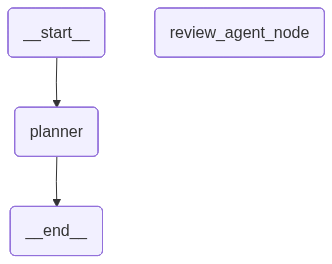

In [21]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [26]:
print(master_df.shape)
print(master_df.columns.tolist())

(112650, 29)
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_score', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_category_name', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'product_category_name_english', 'delay_flag', 'seller_delay_rate', 'category_review_score', 'seller_review_score', 'order_volume']


## Delivery Agent

In [27]:
# delivery days columns is missing


In [28]:
master_df['order_purchase_timestamp'] = pd.to_datetime(master_df['order_purchase_timestamp'])
master_df['order_delivered_customer_date'] = pd.to_datetime(master_df['order_delivered_customer_date'])

master_df['delivery_days'] = (master_df['order_delivered_customer_date'] - master_df['order_purchase_timestamp']).dt.days

print(master_df[['delivery_days']].describe())
print(master_df.shape)

       delivery_days
count  110196.000000
mean       12.007723
std         9.451455
min         0.000000
25%         6.000000
50%        10.000000
75%        15.000000
max       209.000000
(112650, 30)


In [29]:
master_df.to_csv('data/processed/master_df.csv', index=False)
print("Re-saved with delivery_days. Shape:", master_df.shape)

Re-saved with delivery_days. Shape: (112650, 30)


In [30]:
def delivery_agent(state: InsightAgentState) -> dict:
    df = master_df

    avg_delivery_days = df['delivery_days'].mean()
    overall_delay_rate = df['delay_flag'].mean()

    state_delay = (
        df.dropna(subset=['delay_flag'])
          .groupby('customer_state')['delay_flag']
          .mean()
          .sort_values(ascending=False)
          .head(5)
    )

    findings = {
        'avg_delivery_days': round(avg_delivery_days, 2),
        'overall_delay_rate': round(overall_delay_rate, 4),
        'worst_states_by_delay_rate': state_delay.round(4).to_dict(),
    }

    return {'delivery_findings': findings}

In [31]:
test_state = {'user_question': 'test', 'investigation_type': ['delivery']}
print(delivery_agent(test_state))

{'delivery_findings': {'avg_delivery_days': np.float64(12.01), 'overall_delay_rate': np.float64(0.0791), 'worst_states_by_delay_rate': {'AL': 0.24121779859484777, 'MA': 0.20375, 'SE': 0.16266666666666665, 'PI': 0.15487571701720843, 'CE': 0.15287517531556802}}}


## Seller agent


In [32]:
def seller_agent(state: InsightAgentState) -> dict:
    df = master_df

    # Build a per-seller summary: review score, delay rate, and volume
    seller_summary = (
        df.groupby('seller_id')
          .agg(
              seller_review_score=('review_score', 'mean'),
              seller_delay_rate=('delay_flag', 'mean'),
              order_volume=('order_id', 'count')
          )
    )

    # Only consider sellers with a meaningful volume (avoid noisy small-sample sellers)
    MIN_ORDERS = 10
    reliable_sellers = seller_summary[seller_summary['order_volume'] >= MIN_ORDERS]

    worst_by_delay = (
        reliable_sellers.sort_values('seller_delay_rate', ascending=False)
        .head(5)
    )

    worst_by_review = (
        reliable_sellers.sort_values('seller_review_score', ascending=True)
        .head(5)
    )

    findings = {
        'total_sellers': df['seller_id'].nunique(),
        'sellers_with_min_volume': reliable_sellers.shape[0],
        'worst_sellers_by_delay_rate': worst_by_delay.round(4).to_dict(orient='index'),
        'worst_sellers_by_review_score': worst_by_review.round(4).to_dict(orient='index'),
    }

    return {'seller_findings': findings}

In [33]:
test_state = {'user_question': 'test', 'investigation_type': ['seller']}
result = seller_agent(test_state)
print("Total sellers:", result['seller_findings']['total_sellers'])
print("Sellers with min volume:", result['seller_findings']['sellers_with_min_volume'])
print()
print("Worst by delay rate:")
for seller, stats in result['seller_findings']['worst_sellers_by_delay_rate'].items():
    print(f"  {seller}: {stats}")
print()
print("Worst by review score:")
for seller, stats in result['seller_findings']['worst_sellers_by_review_score'].items():
    print(f"  {seller}: {stats}")

Total sellers: 3095
Sellers with min volume: 1381

Worst by delay rate:
  b1b3948701c5c72445495bd161b83a4c: {'seller_review_score': 1.7222, 'seller_delay_rate': 0.6428571428571429, 'order_volume': 18}
  8d899e15a5925f097cca50faa49b15e3: {'seller_review_score': 2.5, 'seller_delay_rate': 0.6, 'order_volume': 10}
  312ba1d77e9c332ef21f9598b7f64cd7: {'seller_review_score': 2.7, 'seller_delay_rate': 0.5714285714285714, 'order_volume': 10}
  4342d4b2ba6b161468c63a7e7cfce593: {'seller_review_score': 1.2632, 'seller_delay_rate': 0.5, 'order_volume': 20}
  2709af9587499e95e803a6498a5a56e9: {'seller_review_score': 2.5652, 'seller_delay_rate': 0.5, 'order_volume': 47}

Worst by review score:
  4342d4b2ba6b161468c63a7e7cfce593: {'seller_review_score': 1.2632, 'seller_delay_rate': 0.5, 'order_volume': 20}
  b37c4c02bda3161a7546a4e6d222d5b2: {'seller_review_score': 1.4, 'seller_delay_rate': 0.06666666666666667, 'order_volume': 15}
  8bd0e3abda539b9479c4b44a691be1ec: {'seller_review_score': 1.6923, '

## Category Agent

In [34]:
def category_agent(state: InsightAgentState) -> dict:
    df = master_df

    category_summary = (
        df.groupby('product_category_name_english')
          .agg(
              category_review_score=('review_score', 'mean'),
              category_delay_rate=('delay_flag', 'mean'),
              order_volume=('order_id', 'count')
          )
    )

    MIN_ORDERS = 30  # categories tend to have higher volume than individual sellers, so a higher threshold makes sense
    reliable_categories = category_summary[category_summary['order_volume'] >= MIN_ORDERS]

    worst_by_review = (
        reliable_categories.sort_values('category_review_score', ascending=True)
        .head(5)
    )

    worst_by_delay = (
        reliable_categories.sort_values('category_delay_rate', ascending=False)
        .head(5)
    )

    findings = {
        'total_categories': df['product_category_name_english'].nunique(),
        'categories_with_min_volume': reliable_categories.shape[0],
        'worst_categories_by_review_score': worst_by_review.round(4).to_dict(orient='index'),
        'worst_categories_by_delay_rate': worst_by_delay.round(4).to_dict(orient='index'),
    }

    return {'category_findings': findings}

In [35]:
test_state = {'user_question': 'test', 'investigation_type': ['category']}
result = category_agent(test_state)
print("Total categories:", result['category_findings']['total_categories'])
print("Categories with min volume:", result['category_findings']['categories_with_min_volume'])
print()
print("Worst by review score:")
for cat, stats in result['category_findings']['worst_categories_by_review_score'].items():
    print(f"  {cat}: {stats}")
print()
print("Worst by delay rate:")
for cat, stats in result['category_findings']['worst_categories_by_delay_rate'].items():
    print(f"  {cat}: {stats}")

Total categories: 71
Categories with min volume: 66

Worst by review score:
  diapers_and_hygiene: {'category_review_score': 3.2564, 'category_delay_rate': 0.02702702702702703, 'order_volume': 39}
  office_furniture: {'category_review_score': 3.4884, 'category_delay_rate': 0.08932853717026379, 'order_volume': 1691}
  home_comfort_2: {'category_review_score': 3.6296, 'category_delay_rate': 0.16666666666666666, 'order_volume': 30}
  fashion_male_clothing: {'category_review_score': 3.6412, 'category_delay_rate': 0.056, 'order_volume': 132}
  fixed_telephony: {'category_review_score': 3.682, 'category_delay_rate': 0.043137254901960784, 'order_volume': 264}

Worst by delay rate:
  home_comfort_2: {'category_review_score': 3.6296, 'category_delay_rate': 0.16666666666666666, 'order_volume': 30}
  furniture_mattress_and_upholstery: {'category_review_score': 3.8158, 'category_delay_rate': 0.13513513513513514, 'order_volume': 38}
  audio: {'category_review_score': 3.8333, 'category_delay_rate': 

In [39]:
def route_after_planner(state: InsightAgentState):
    domain_to_node = {
        'review': 'review_agent_node',
        'delivery': 'delivery_agent_node',
        'seller': 'seller_agent_node',
        'category': 'category_agent_node',
    }
    next_nodes = [domain_to_node[d] for d in state['investigation_type']]
    return next_nodes if next_nodes else END

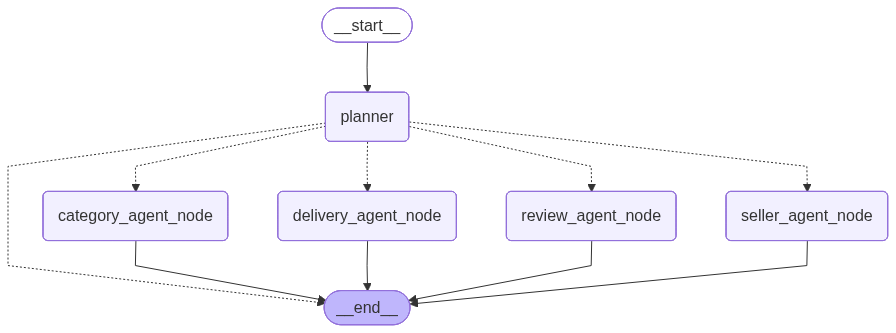

In [40]:
graph_builder = StateGraph(InsightAgentState)

graph_builder.add_node("planner", planner_agent)
graph_builder.add_node("review_agent_node", review_agent)
graph_builder.add_node("delivery_agent_node", delivery_agent)
graph_builder.add_node("seller_agent_node", seller_agent)
graph_builder.add_node("category_agent_node", category_agent)

graph_builder.add_edge(START, "planner")

graph_builder.add_conditional_edges(
    "planner",
    route_after_planner,
    {
        "review_agent_node": "review_agent_node",
        "delivery_agent_node": "delivery_agent_node",
        "seller_agent_node": "seller_agent_node",
        "category_agent_node": "category_agent_node",
        END: END
    }
)

graph_builder.add_edge("review_agent_node", END)
graph_builder.add_edge("delivery_agent_node", END)
graph_builder.add_edge("seller_agent_node", END)
graph_builder.add_edge("category_agent_node", END)

graph = graph_builder.compile()

from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [41]:
result = graph.invoke({"user_question": "Which sellers contribute most to delays?"})
print("Domains triggered:", result['investigation_type'])
print("Has review_findings:", 'review_findings' in result)
print("Has delivery_findings:", 'delivery_findings' in result)
print("Has seller_findings:", 'seller_findings' in result)
print("Has category_findings:", 'category_findings' in result)

Domains triggered: ['delivery', 'seller']
Has review_findings: False
Has delivery_findings: True
Has seller_findings: True
Has category_findings: False


In [42]:
def root_cause_agent(state: InsightAgentState) -> dict:
    causes = []

    # Evidence from Review Agent
    if state.get('review_findings'):
        rf = state['review_findings']
        avg = float(rf['avg_review_score'])
        delayed_avg = float(rf['delayed_order_review_score'])
        ontime_avg = float(rf['ontime_order_review_score'])
        gap = round(ontime_avg - delayed_avg, 2)

        if gap > 1.0:  # more than 1 point gap is a strong signal
            causes.append({
                'cause': 'Delivery delays driving customer dissatisfaction',
                'evidence': f'Delayed orders average {delayed_avg} stars vs {ontime_avg} for on-time orders — a {gap} point gap',
                'severity': gap  # larger gap = higher severity = ranks higher
            })

        if avg < 4.0:
            causes.append({
                'cause': 'Overall customer satisfaction below platform benchmark',
                'evidence': f'Average review score is {avg}/5.0',
                'severity': round(4.0 - avg, 2)
            })

    # Evidence from Delivery Agent
    if state.get('delivery_findings'):
        df = state['delivery_findings']
        delay_rate = float(df['overall_delay_rate'])
        avg_days = float(df['avg_delivery_days'])
        worst_states = df['worst_states_by_delay_rate']

        if delay_rate > 0.05:  # more than 5% delay rate is notable
            causes.append({
                'cause': 'Significant delivery delay rate across platform',
                'evidence': f'{round(delay_rate*100, 1)}% of orders delayed, averaging {avg_days} days delivery time',
                'severity': round(delay_rate * 10, 4)
            })

        top_state = list(worst_states.keys())[0]
        top_rate = round(float(list(worst_states.values())[0]) * 100, 1)
        if top_rate > 15:
            causes.append({
                'cause': f'Regional delivery concentration — {top_state} severely underserved',
                'evidence': f'{top_state} has {top_rate}% delay rate vs {round(delay_rate*100,1)}% national average',
                'severity': round(top_rate / 100, 4)
            })

    # Evidence from Seller Agent
    if state.get('seller_findings'):
        sf = state['seller_findings']
        worst_delay = list(sf['worst_sellers_by_delay_rate'].values())[0]
        worst_review = list(sf['worst_sellers_by_review_score'].values())[0]

        if float(worst_delay['seller_delay_rate']) > 0.3:
            causes.append({
                'cause': 'High-risk sellers with extreme delay rates',
                'evidence': f'Top problem seller has {round(float(worst_delay["seller_delay_rate"])*100,1)}% delay rate and {round(float(worst_delay["seller_review_score"]),2)} avg review score',
                'severity': float(worst_delay['seller_delay_rate'])
            })

        if float(worst_review['seller_review_score']) < 2.0:
            causes.append({
                'cause': 'Critically underperforming sellers dragging platform rating',
                'evidence': f'Worst seller averages only {round(float(worst_review["seller_review_score"]),2)}/5.0 review score',
                'severity': round(2.0 - float(worst_review['seller_review_score']), 4)
            })

    # Evidence from Category Agent
    if state.get('category_findings'):
        cf = state['category_findings']
        worst_cat_review = list(cf['worst_categories_by_review_score'].items())[0]
        worst_cat_delay = list(cf['worst_categories_by_delay_rate'].items())[0]

        if float(worst_cat_review[1]['category_review_score']) < 3.5:
            causes.append({
                'cause': f'Category-specific quality issues — {worst_cat_review[0]} underperforming',
                'evidence': f'{worst_cat_review[0]} averages {round(float(worst_cat_review[1]["category_review_score"]),2)}/5.0 with only {round(float(worst_cat_review[1]["category_delay_rate"])*100,1)}% delay rate (not a delivery problem)',
                'severity': round(3.5 - float(worst_cat_review[1]['category_review_score']), 4)
            })

        if float(worst_cat_delay[1]['category_delay_rate']) > 0.12:
            causes.append({
                'cause': f'Category-specific delivery failures — {worst_cat_delay[0]} severely delayed',
                'evidence': f'{worst_cat_delay[0]} has {round(float(worst_cat_delay[1]["category_delay_rate"])*100,1)}% delay rate',
                'severity': float(worst_cat_delay[1]['category_delay_rate'])
            })

    # Rank by severity descending
    causes.sort(key=lambda x: x['severity'], reverse=True)

    summary = {
        'total_causes_identified': len(causes),
        'ranked_causes': causes
    }

    return {'root_cause_summary': summary}

In [43]:
test_result = graph.invoke({"user_question": "Which factors affect customer ratings the most?"})
root_state = root_cause_agent(test_result)
summary = root_state['root_cause_summary']
print(f"Total causes identified: {summary['total_causes_identified']}")
print()
for i, cause in enumerate(summary['ranked_causes'], 1):
    print(f"Cause #{i}: {cause['cause']}")
    print(f"  Evidence: {cause['evidence']}")
    print(f"  Severity score: {cause['severity']}")
    print()

Total causes identified: 7

Cause #1: Delivery delays driving customer dissatisfaction
  Evidence: Delayed orders average 2.55 stars vs 4.21 for on-time orders — a 1.66 point gap
  Severity score: 1.66

Cause #2: Significant delivery delay rate across platform
  Evidence: 7.9% of orders delayed, averaging 12.01 days delivery time
  Severity score: 0.791

Cause #3: Critically underperforming sellers dragging platform rating
  Evidence: Worst seller averages only 1.26/5.0 review score
  Severity score: 0.7368

Cause #4: High-risk sellers with extreme delay rates
  Evidence: Top problem seller has 64.3% delay rate and 1.72 avg review score
  Severity score: 0.6428571428571429

Cause #5: Category-specific quality issues — diapers_and_hygiene underperforming
  Evidence: diapers_and_hygiene averages 3.26/5.0 with only 2.7% delay rate (not a delivery problem)
  Severity score: 0.2436

Cause #6: Regional delivery concentration — AL severely underserved
  Evidence: AL has 24.1% delay rate vs 7.

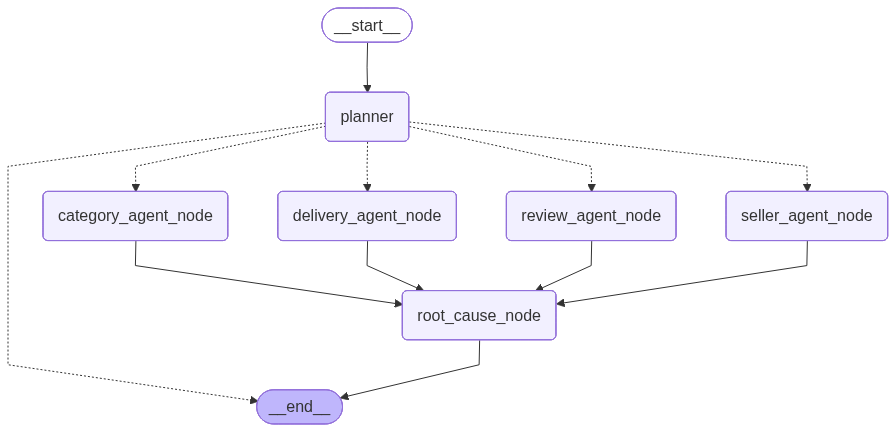

In [44]:
# Update route_after_planner to point to root_cause_node instead of END
def route_after_planner(state: InsightAgentState):
    domain_to_node = {
        'review': 'review_agent_node',
        'delivery': 'delivery_agent_node',
        'seller': 'seller_agent_node',
        'category': 'category_agent_node',
    }
    next_nodes = [domain_to_node[d] for d in state['investigation_type']]
    return next_nodes if next_nodes else END

# Rebuild graph with root cause agent added
graph_builder = StateGraph(InsightAgentState)
graph_builder.add_node("planner", planner_agent)
graph_builder.add_node("review_agent_node", review_agent)
graph_builder.add_node("delivery_agent_node", delivery_agent)
graph_builder.add_node("seller_agent_node", seller_agent)
graph_builder.add_node("category_agent_node", category_agent)
graph_builder.add_node("root_cause_node", root_cause_agent)

graph_builder.add_edge(START, "planner")
graph_builder.add_conditional_edges(
    "planner",
    route_after_planner,
    {
        "review_agent_node": "review_agent_node",
        "delivery_agent_node": "delivery_agent_node",
        "seller_agent_node": "seller_agent_node",
        "category_agent_node": "category_agent_node",
        END: END
    }
)

# All 4 analysis agents now feed into root_cause_node (not END directly)
graph_builder.add_edge("review_agent_node", "root_cause_node")
graph_builder.add_edge("delivery_agent_node", "root_cause_node")
graph_builder.add_edge("seller_agent_node", "root_cause_node")
graph_builder.add_edge("category_agent_node", "root_cause_node")
graph_builder.add_edge("root_cause_node", END)

graph = graph_builder.compile()

from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [46]:
result = graph.invoke({
    "user_question": "Why are cutomer reviews are low?"
})

# Print root cause summary cleanly
summary = result['root_cause_summary']
print(f"Question: {result['user_question']}")
print(f"Domains investigated: {result['investigation_type']}")
print(f"Total causes identified: {summary['total_causes_identified']}")
print()
for i, cause in enumerate(summary['ranked_causes'], 1):
    print(f"Cause #{i}: {cause['cause']}")
    print(f"  Evidence: {cause['evidence']}")
    print(f"  Severity: {cause['severity']}")
    print()

Question: Why are cutomer reviews are low?
Domains investigated: ['review']
Total causes identified: 1

Cause #1: Delivery delays driving customer dissatisfaction
  Evidence: Delayed orders average 2.55 stars vs 4.21 for on-time orders — a 1.66 point gap
  Severity: 1.66



In [47]:
result = graph.invoke({
    "user_question": "Which product categories experience the most delays?"
})

summary = result['root_cause_summary']
print(f"Question: {result['user_question']}")
print(f"Domains investigated: {result['investigation_type']}")
print(f"Total causes identified: {summary['total_causes_identified']}")
print()
for i, cause in enumerate(summary['ranked_causes'], 1):
    print(f"Cause #{i}: {cause['cause']}")
    print(f"  Evidence: {cause['evidence']}")
    print(f"  Severity: {cause['severity']}")
    print()

Question: Which product categories experience the most delays?
Domains investigated: ['delivery', 'category']
Total causes identified: 4

Cause #1: Significant delivery delay rate across platform
  Evidence: 7.9% of orders delayed, averaging 12.01 days delivery time
  Severity: 0.791

Cause #2: Category-specific quality issues — diapers_and_hygiene underperforming
  Evidence: diapers_and_hygiene averages 3.26/5.0 with only 2.7% delay rate (not a delivery problem)
  Severity: 0.2436

Cause #3: Regional delivery concentration — AL severely underserved
  Evidence: AL has 24.1% delay rate vs 7.9% national average
  Severity: 0.241

Cause #4: Category-specific delivery failures — home_comfort_2 severely delayed
  Evidence: home_comfort_2 has 16.7% delay rate
  Severity: 0.16666666666666666



In [53]:
from dotenv import load_dotenv, dotenv_values
import os

load_dotenv(r'C:\Users\Aanchal Shah\OneDrive\Desktop\InsightAgent\.env', override=True)
api_key = os.getenv('GROQ_API_KEY')
print("Key loaded:", api_key[:8] + "..." if api_key else "NOT FOUND")

Key loaded: gsk_tDMV...


In [56]:
from groq import Groq

def report_agent(state: InsightAgentState) -> dict:
    question = state['user_question']
    investigation_type = state['investigation_type']
    root_cause_summary = state['root_cause_summary']

    causes_text = "\n".join([
        f"{i+1}. {c['cause']}: {c['evidence']} (severity: {round(float(c['severity']),3)})"
        for i, c in enumerate(root_cause_summary['ranked_causes'])
    ])

    prompt = f"""You are a senior business analyst writing an executive report.

Business Question: {question}
Domains Investigated: {', '.join(investigation_type)}
Total Causes Identified: {root_cause_summary['total_causes_identified']}

Ranked Root Causes (by severity):
{causes_text}

Write a professional executive report with these exact sections:
- Executive Summary (2-3 sentences)
- Key Findings (bullet points with specific numbers)
- Root Cause Analysis (ranked causes with business impact)
- Recommendations (3-4 actionable items)

Be concise, data-driven, and professional. Use the exact numbers provided."""

    try:
        client = Groq(api_key=os.getenv('GROQ_API_KEY'))
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=1000,
            temperature=0.3
        )
        final_report = response.choices[0].message.content
    except Exception as e:
        final_report = f"LLM unavailable ({e}). Causes: {causes_text}"

    return {'final_report': final_report}

In [57]:
test_result = graph.invoke({
    "user_question": "Which factors affect customer ratings the most?"
})
report_output = report_agent(test_result)
print(report_output['final_report'])

**Executive Summary**
This report investigates the factors affecting customer ratings, identifying seven key causes with significant business impact. The analysis reveals that delivery-related issues and underperforming sellers are the primary drivers of customer dissatisfaction, with a notable gap in average review scores between delayed and on-time orders. By addressing these root causes, the platform can improve overall customer satisfaction and increase average review scores.

**Key Findings**
* Delayed orders average 2.55 stars, compared to 4.21 stars for on-time orders, resulting in a 1.66 point gap
* 7.9% of orders are delayed, with an average delivery time of 12.01 days
* The worst-performing seller averages only 1.26/5.0 review score, while the top problem seller has a 64.3% delay rate and 1.72 average review score
* The diapers_and_hygiene category averages 3.26/5.0 review score, despite a low 2.7% delay rate
* Alabama (AL) has a 24.1% delay rate, significantly higher than th

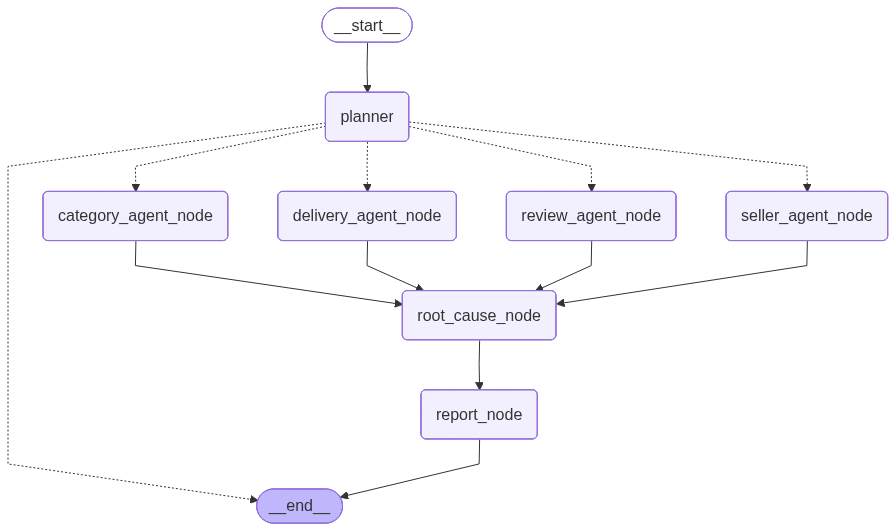

In [59]:
graph_builder = StateGraph(InsightAgentState)
graph_builder.add_node("planner", planner_agent)
graph_builder.add_node("review_agent_node", review_agent)
graph_builder.add_node("delivery_agent_node", delivery_agent)
graph_builder.add_node("seller_agent_node", seller_agent)
graph_builder.add_node("category_agent_node", category_agent)
graph_builder.add_node("root_cause_node", root_cause_agent)
graph_builder.add_node("report_node", report_agent)  # added

graph_builder.add_edge(START, "planner")
graph_builder.add_conditional_edges("planner", route_after_planner, {
    "review_agent_node": "review_agent_node",
    "delivery_agent_node": "delivery_agent_node",
    "seller_agent_node": "seller_agent_node",
    "category_agent_node": "category_agent_node",
    END: END
})
graph_builder.add_edge("review_agent_node", "root_cause_node")
graph_builder.add_edge("delivery_agent_node", "root_cause_node")
graph_builder.add_edge("seller_agent_node", "root_cause_node")
graph_builder.add_edge("category_agent_node", "root_cause_node")
graph_builder.add_edge("root_cause_node", "report_node")  # added
graph_builder.add_edge("report_node", END)  # added

graph = graph_builder.compile()

from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [61]:
from IPython.display import Markdown
result = graph.invoke({"user_question": "Which sellers should be investigated?"})
display(Markdown(result['final_report']))

**Executive Summary**
This report identifies underperforming sellers that require immediate investigation to mitigate the risk of damaging the platform's reputation. The analysis reveals two primary causes of concern, with critically underperforming sellers and high-risk sellers with extreme delay rates being the main culprits. By addressing these issues, we can improve the overall customer experience and platform rating.

**Key Findings**
* The worst seller has an average review score of 1.26/5.0, indicating a significant gap in performance.
* The top problem seller has a delay rate of 64.3% and an average review score of 1.72, posing a substantial risk to the platform.
* The severity of these issues is measured at 0.737 and 0.643, respectively, highlighting the need for prompt action.

**Root Cause Analysis**
The ranked root causes of the problem are:
1. Critically underperforming sellers dragging platform rating, with a severity of 0.737, resulting in a significant negative impact on the platform's overall reputation.
2. High-risk sellers with extreme delay rates, with a severity of 0.643, leading to customer dissatisfaction and potential loss of business.

**Recommendations**
To address these issues, we recommend the following:
1. Investigate and potentially terminate contracts with sellers having an average review score below 2.0, starting with the worst performer (1.26/5.0).
2. Implement additional monitoring and support for sellers with high delay rates, such as the top problem seller with a 64.3% delay rate.
3. Develop and enforce stricter performance metrics and consequences for non-compliance to prevent similar issues in the future.
4. Provide targeted training and resources to help underperforming sellers improve their services and increase customer satisfaction.